# Demo of Bayesian NMF
+ Here, we compare several methods for NMF: EM, VB, MCMC
+ For comparison, we will use generalized loss and train loss if I have enough room.

# Setting

## Data

In [1]:
%matplotlib inline

In [121]:
from collections import namedtuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, psi, logsumexp, softmax

In [3]:
M, H0, N = (30, 10, 30)

In [4]:
data_seed = 20251014
np.random.seed(data_seed)
true_A = np.random.gamma(shape=1, scale=1, size=(M, H0))
true_B = np.random.gamma(shape=1, scale=1, size=(H0, N))

In [5]:
n = 1
train_X = np.random.poisson(true_A @ true_B, size=(n, M, N)).squeeze()

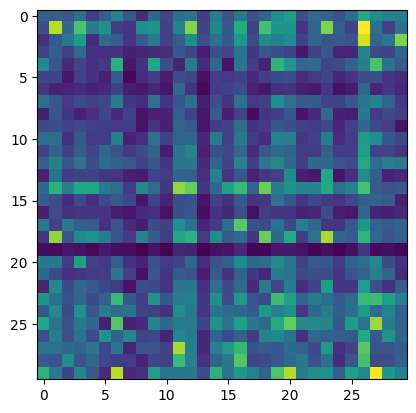

In [6]:
plt.imshow(true_A @ true_B)

# Gibbs Sampling
+ A and B is sampled from Gamma distribution, and the latent variable is sampled from multinomial distribution.

## learning settings

### hyperparameters

In [7]:
pri_alpha = 0.1
pri_beta = 1
pri_gamma = 0.1
pri_delta = 1

### intermediate dimension

In [8]:
H = 15

### others

In [9]:
ln_seed = 20241014
np.random.seed(ln_seed)

In [10]:
est_A = np.random.gamma(shape=1, scale=1, size=(M, H))
est_B = np.random.gamma(shape=1, scale=1, size=(H, N))

### one loop

In [11]:
numerator = (est_A[:,:,np.newaxis] * est_B[np.newaxis,: ,:])
est_P = numerator / numerator.sum(axis=1)[:,np.newaxis,:]
est_S = np.zeros_like(est_P)
nonzero_idx = np.nonzero(train_X)
ii = nonzero_idx[0]
jj = nonzero_idx[1]

for n in range(len(ii)):
    i = ii[n]
    j = jj[n]
    x_ij = train_X[i, j]
    if x_ij > 0:
        # pは shape (K,) にする
        p_ij = est_P[i, :, j]
        est_S[i, :, j] = np.random.multinomial(x_ij, p_ij)

In [12]:
est_alpha = est_S.sum(axis=2) + pri_alpha

est_beta = est_B.sum(axis=1) + pri_beta
est_beta = np.repeat(est_beta, M).reshape((H,M)).T
est_A = np.random.gamma(shape=est_alpha, scale=1/est_beta, size=(M, H))

In [13]:
est_gamma = est_S.sum(axis=0) + pri_gamma
est_delta = est_A.sum(axis=0) + pri_delta
est_delta = np.repeat(est_delta, N).reshape((H, N))
est_B = np.random.gamma(shape=est_gamma, scale=1/est_delta, size=(H, N))

## Burn-in and each samples

In [14]:
def sample_from_S(train_X: np.ndarray, est_A: np.ndarray, est_B: np.ndarray) -> np.ndarray:
    numerator = (est_A[:,:,np.newaxis] * est_B[np.newaxis,: ,:])
    est_P = numerator / numerator.sum(axis=1)[:,np.newaxis,:]
    est_S = np.zeros_like(est_P)
    nonzero_idx = np.nonzero(train_X)
    ii = nonzero_idx[0]
    jj = nonzero_idx[1]
    
    for n in range(len(ii)):
        i = ii[n]
        j = jj[n]
        x_ij = train_X[i, j]
        if x_ij > 0:
            # pは shape (K,) にする
            p_ij = est_P[i, :, j]
            est_S[i, :, j] = np.random.multinomial(x_ij, p_ij)
    return est_S
    
def sample_from_A(est_B: np.ndarray, est_S: np.ndarray, pri_alpha: float, pri_beta: float) -> np.ndarray:
    M, H, _ = est_S.shape
    
    est_alpha = est_S.sum(axis=2) + pri_alpha
    est_beta = est_B.sum(axis=1) + pri_beta
    est_beta = np.repeat(est_beta, M).reshape((H,M)).T
    est_A = np.random.gamma(shape=est_alpha, scale=1/est_beta, size=(M, H))
    return est_A

def sample_from_B(est_A: np.ndarray, est_S: np.ndarray, pri_gamma: float, pri_delta: float) -> np.ndarray:
    _, H, N = est_S.shape
    
    est_gamma = est_S.sum(axis=0) + pri_gamma
    est_delta = est_A.sum(axis=0) + pri_delta
    est_delta = np.repeat(est_delta, N).reshape((H, N))
    est_B = np.random.gamma(shape=est_gamma, scale=1/est_delta, size=(H, N))
    return est_B

In [15]:
burnin = 5000
step = 5
sample_num = 1000
n_iter = burnin + step * sample_num

In [16]:
SampledParams = namedtuple('SampledParams', ['A', 'B', 'S'])
est_results: list[SampledParams] = []

In [17]:
ln_seed = 20241014
np.random.seed(ln_seed)

In [18]:
est_A = np.random.gamma(shape=1, scale=1, size=(M, H))
est_B = np.random.gamma(shape=1, scale=1, size=(H, N))

In [19]:
for _ in range(n_iter):
    est_S = sample_from_S(train_X, est_A, est_B)
    est_A = sample_from_A(est_B, est_S, pri_alpha, pri_beta)
    est_B = sample_from_B(est_A, est_S, pri_gamma, pri_delta)
    # burnin, step以外のサンプルは除く場合は条件を入れる
    est_results.append(SampledParams(A=est_A, B=est_B, S=est_S))

In [21]:
post_params = est_results[burnin:][::step]

In [23]:
mean_AB_bef_burnin = np.array([
    post_param.A @ post_param.B
    for post_param in est_results[:burnin]
]).mean(axis=0)

In [24]:
mean_AB = np.array([
    post_param.A @ post_param.B
    for post_param in post_params
]).mean(axis=0)

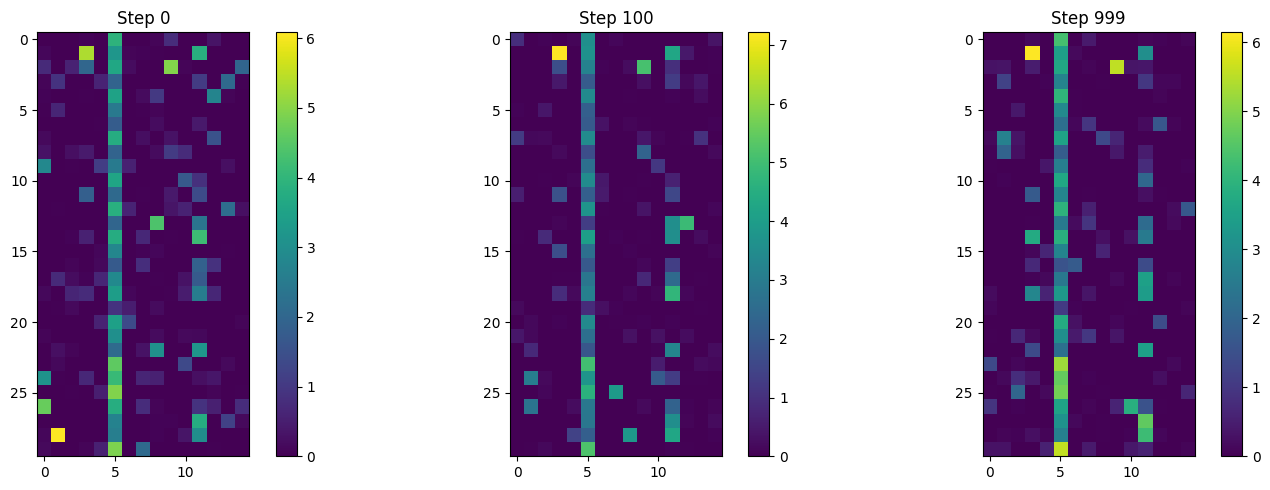

In [158]:
# 途中過程を並べて比較
# タイミングのインデックス
n = len(post_params)
# indices = [0, n // 2, n - 1]
indices = [0, 100, n - 1]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.imshow(post_params[idx].A)
    plt.title(f"Step {idx}")
    plt.colorbar()
plt.tight_layout()
plt.show()

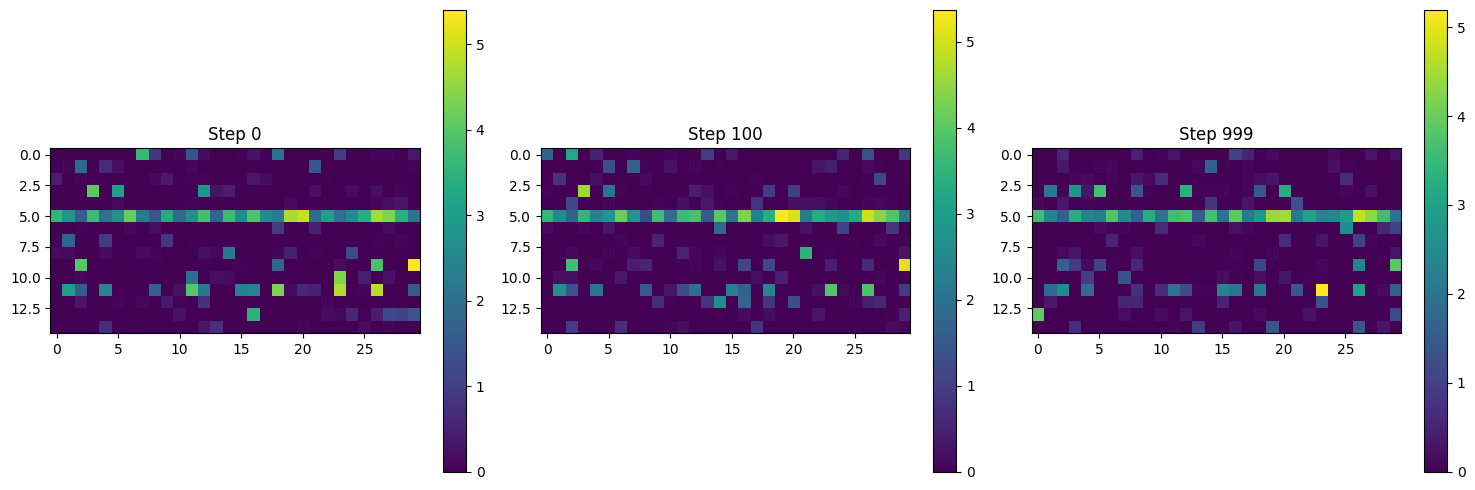

In [159]:
# 途中過程を並べて比較
# タイミングのインデックス
n = len(post_params)
# indices = [0, n // 2, n - 1]
indices = [0, 100, n - 1]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.imshow(post_params[idx].B)
    plt.title(f"Step {idx}")
    plt.colorbar()
plt.tight_layout()
plt.show()

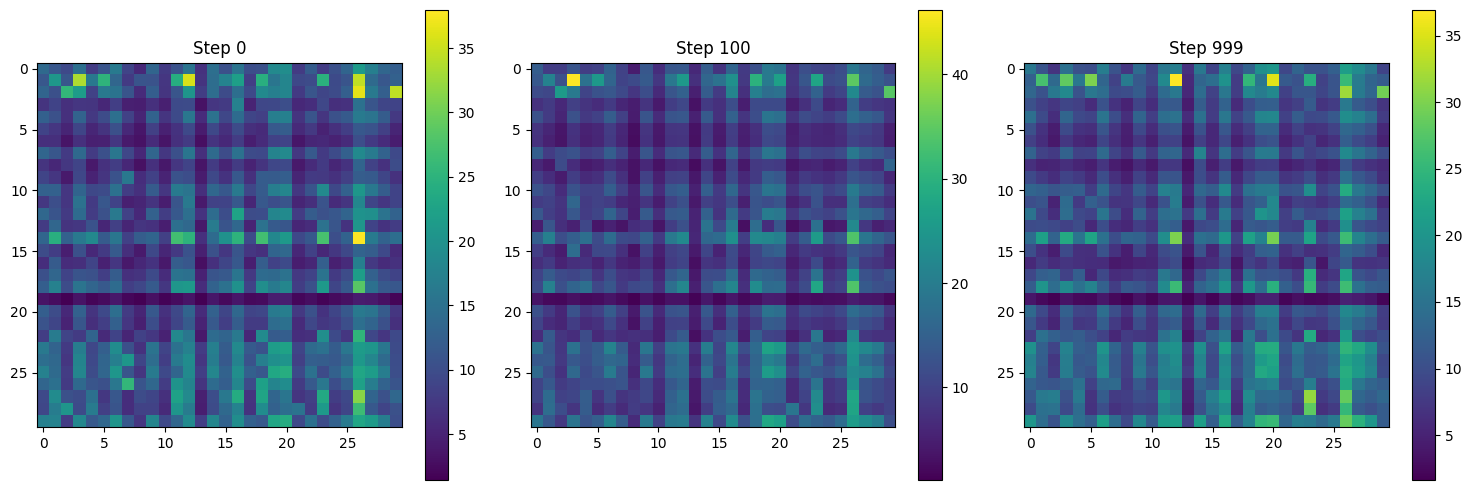

In [160]:
# 途中過程を並べて比較
# タイミングのインデックス
n = len(post_params)
# indices = [0, n // 2, n - 1]
indices = [0, 100, n - 1]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.imshow(post_params[idx].A @ post_params[idx].B)
    plt.title(f"Step {idx}")
    plt.colorbar()
plt.tight_layout()
plt.show()

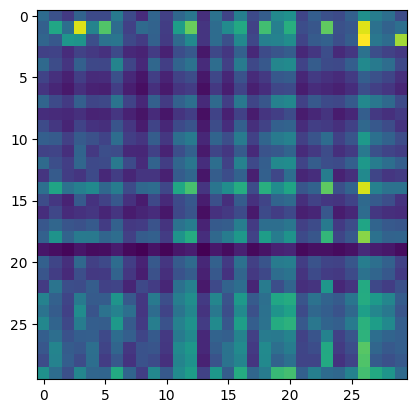

In [26]:
plt.imshow(mean_AB)

In [38]:
(np.abs(true_A @ true_B - mean_AB)**2).mean()  # MSE

np.float64(8.100079943603022)

In [39]:
# remove unnecessary variables
del est_results, est_A, est_B, est_S

# Variational Bayes

## one loop

In [73]:
est_S = np.random.dirichlet([1]*H, size=(N, M)).transpose((0, 2, 1))
est_B = np.random.gamma(shape=1, scale=1, size=(H, N))

In [74]:
est_alpha = (train_X[:,np.newaxis,:] * est_S).sum(axis=2) + pri_alpha
est_beta = est_B.sum(axis=1)[np.newaxis,:] + pri_beta
# np.repeat(est_B.sum(axis=1), M).reshape((H, M)).T + pri_beta
est_loga = psi(est_alpha) - np.log(est_beta)
est_A = est_alpha / est_beta

In [75]:
est_gamma = (train_X[:,np.newaxis,:] * est_S).sum(axis=0) + pri_gamma
est_delta = est_A.sum(axis=0)[:,np.newaxis] + pri_delta
est_logb = psi(est_gamma) - np.log(est_delta)
est_B = est_gamma / est_delta

## Variational Bayes step

In [122]:
def vb_update_S(est_alpha: np.ndarray, est_beta: np.ndarray, est_gamma: np.ndarray, est_delta: np.ndarray) -> np.ndarray:
    est_loga = psi(est_alpha) - np.log(est_beta)
    est_logb = psi(est_gamma) - np.log(est_delta)

    est_xi = est_loga[:,:,np.newaxis] + est_logb[np.newaxis,:,:]
    est_S = softmax(est_xi, axis=1)    
    # numerator = np.exp(est_xi)
    # est_S = numerator / numerator.sum(axis=1)[:,np.newaxis,:]
    return est_S, est_xi

def vb_update_A(train_X: np.ndarray, est_S: np.ndarray, est_B: np.ndarray, pri_alpha: float, pri_beta: float) -> np.ndarray:
    est_alpha = (train_X[:,np.newaxis,:] * est_S).sum(axis=2) + pri_alpha
    est_beta = est_B.sum(axis=1)[np.newaxis,:] + pri_beta
    est_A = est_alpha / est_beta

    return est_alpha, est_beta, est_A

def vb_update_B(train_X: np.ndarray, est_S: np.ndarray, est_A: np.ndarray, pri_gamma: float, pri_delta: float) -> np.ndarray:
    est_gamma = (train_X[:,np.newaxis,:] * est_S).sum(axis=0) + pri_gamma
    est_delta = est_A.sum(axis=0)[:,np.newaxis] + pri_delta
    est_B = est_gamma / est_delta
    return est_gamma, est_delta, est_B


## evaluation function

In [138]:
def calc_vb_energy(
    est_alpha: np.ndarray, est_beta: np.ndarray, est_gamma: np.ndarray, est_delta: np.ndarray,
    pri_alpha: float, pri_beta: float, pri_gamma: float, pri_delta: float,
    est_S: np.ndarray,
    train_X: np.ndarray,
    est_A: np.ndarray, est_B: np.ndarray,
    xi: np.ndarray
) -> np.ndarray:
    est_loga = psi(est_alpha) - np.log(est_beta)
    est_logb = psi(est_gamma) - np.log(est_delta)
    
    kl_wa = (
        (est_alpha-pri_alpha)*psi(est_alpha) - gammaln(est_alpha)+gammaln(pri_alpha)
        + pri_alpha*(np.log(est_beta)-np.log(pri_beta)) + est_alpha*(est_beta/pri_beta-1)
    ).sum()
    kl_wb = (
        (est_gamma-pri_gamma)*psi(est_gamma) - gammaln(est_gamma)+gammaln(pri_gamma)
        + pri_gamma*(np.log(est_delta)-np.log(pri_delta)) + est_gamma*(est_delta/pri_delta-1)
    ).sum()

    logp = (
        -est_A@est_B + train_X*(est_S*(est_loga[:,:,np.newaxis]+est_logb[np.newaxis,:,:])-xi).sum(axis=1)
        +logsumexp(xi, axis=1)-gammaln(train_X+1)
    ).sum()

    return kl_wa, kl_wb, logp

In [141]:
ln_seed = 20241014
np.random.seed(ln_seed)

est_S = np.random.dirichlet([1]*H, size=(N, M)).transpose((0, 2, 1))
est_B = np.random.gamma(shape=1, scale=1, size=(H, N))

In [142]:
VBParams = namedtuple('VBParams', ['alpha', 'beta', 'gamma', 'delta', 'xi', 'A', 'B', 'S'])
est_results: list[VBParams] = []
vb_energy = []

In [143]:
n_iter = 1000

In [144]:
for ite in range(n_iter):
    est_alpha, est_beta, est_A = vb_update_A(train_X, est_S, est_B, pri_alpha, pri_beta)
    est_gamma, est_delta, est_B = vb_update_B(train_X, est_S, est_A, pri_gamma, pri_delta)
    est_S, est_xi = vb_update_S(est_alpha, est_beta, est_gamma, est_delta)
    kl_wa, kl_wb, logp = calc_vb_energy(
        est_alpha, est_beta, est_gamma, est_delta,
        pri_alpha, pri_beta, pri_gamma, pri_delta,
        est_S, train_X, est_A, est_B, est_xi
    )
    
    vb_energy.append(kl_wa + kl_wb - logp)
    est_results.append(VBParams(est_alpha, est_beta, est_gamma, est_delta, est_xi, est_A, est_B, est_S))

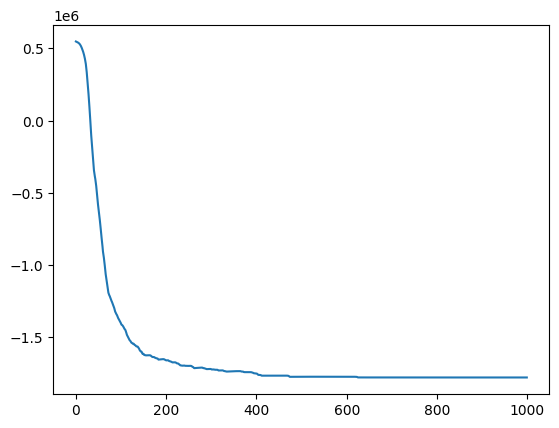

In [147]:
plt.plot(np.arange(len(vb_energy)), np.array(vb_energy))

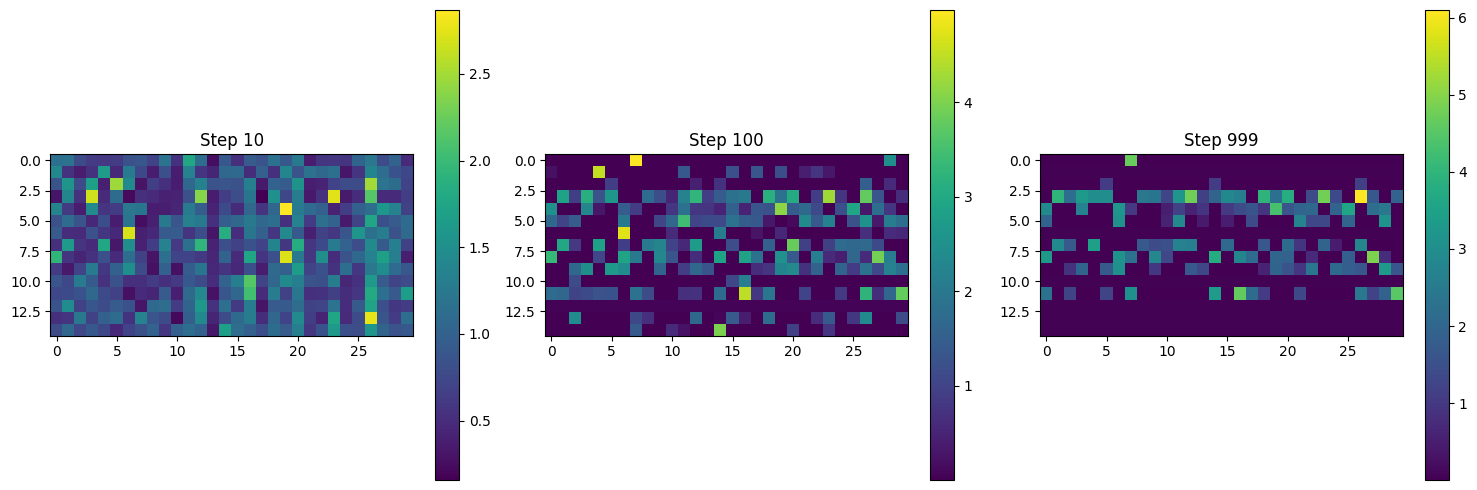

In [152]:
# 途中過程を並べて比較
# タイミングのインデックス
n = len(est_results)
# indices = [0, n // 2, n - 1]
indices = [10, 100, n - 1]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.imshow(est_results[idx].B)
    plt.title(f"Step {idx}")
    plt.colorbar()
plt.tight_layout()
plt.show()

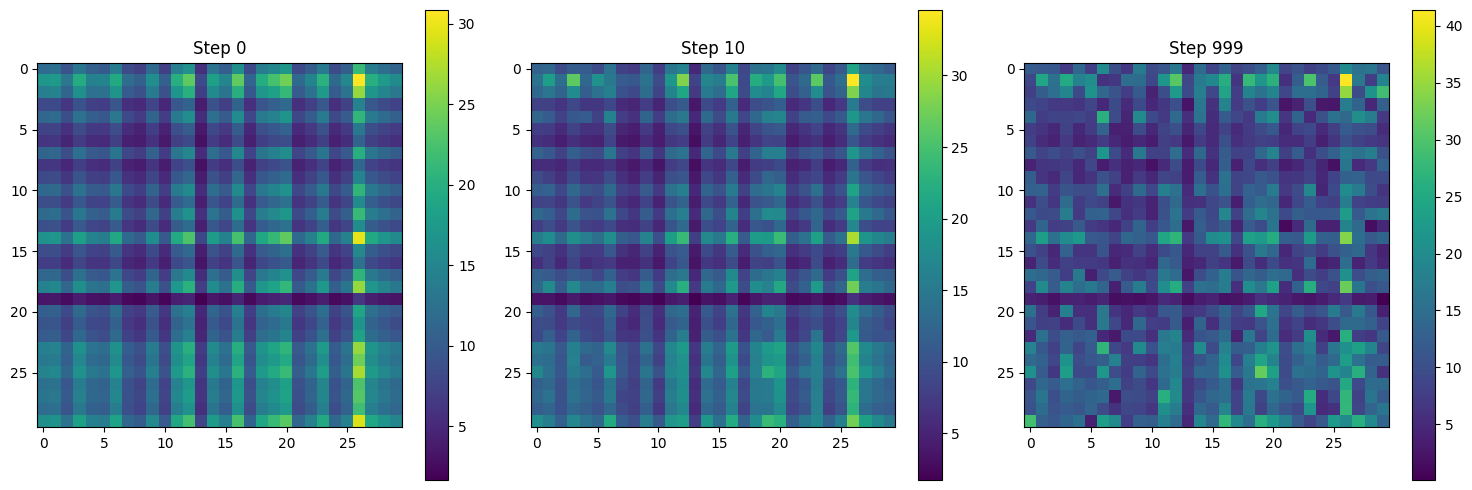

In [154]:
# 途中過程を並べて比較
# タイミングのインデックス
n = len(est_results)
# indices = [0, n // 2, n - 1]
indices = [0, 10, n - 1]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.imshow(est_results[idx].A @ est_results[idx].B)
    plt.title(f"Step {idx}")
    plt.colorbar()
plt.tight_layout()
plt.show()

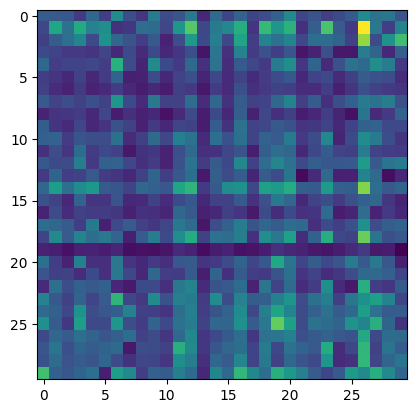

In [98]:
plt.imshow(est_results[-1].A @ est_results[-1].B)